# Experiment 1: Data Preprocessing

Dataset: Iris dataset from UCI Machine Learning Repository

## a) Load the dataset, encode labels, and split into training and testing sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Column names
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
data = pd.read_csv("../iris/iris.data", header=None, names=columns)

# Preprocessing
encoder = LabelEncoder()
data['species'] = encoder.fit_transform(data['species'])

X = data.drop("species", axis=1)
y = data['species']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete.")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

Preprocessing complete.
X_train shape: (120, 4)
X_test shape: (30, 4)


# Experiment 2: ANN Implementation

## b) Build and train an Artificial Neural Network (MLPClassifier)

In [2]:
# Create and train ANN
model = MLPClassifier(hidden_layer_sizes=(10, 8), max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("ANN training complete.")

ANN training complete.


# Experiment 3: Performance Evaluation

## c) Evaluate the model using Accuracy, Confusion Matrix, and Classification Report

In [3]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Metrics
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0000

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Experiment 4: Visualization

## d) Visualize the Confusion Matrix and Training Loss Curve

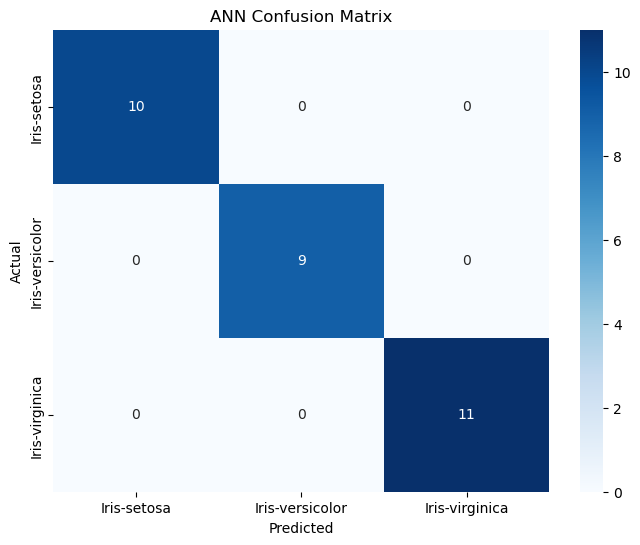

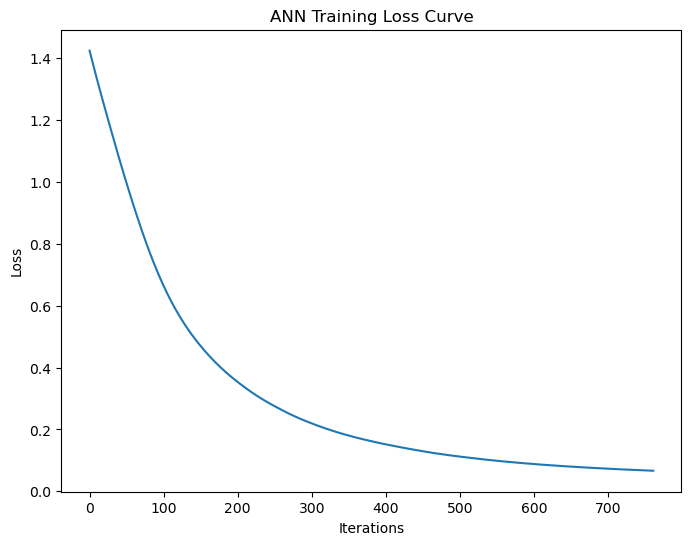

In [4]:
# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN Confusion Matrix')
plt.savefig('outputs/confusion_matrix.png')
plt.show()

# Plotting Loss Curve
plt.figure(figsize=(8, 6))
plt.plot(model.loss_curve_)
plt.title('ANN Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.savefig('outputs/loss_curve.png')
plt.show()

# Questions:

1. **What is an Artificial Neural Network (ANN)?**
   An ANN is a computational model inspired by the structure and function of biological neural networks. It consists of interconnected layers of nodes (neurons) that process data to solve complex learning problems.

2. **Why is feature scaling important for ANNs?**
   Feature scaling (like standardization) is crucial because ANNs use gradient-based optimization. If features have vastly different scales, the gradient updates may oscillate and slow down convergence, or cause bias towards features with larger values.

3. **What is the purpose of hidden layers in an ANN?**
   Hidden layers allow the network to learn non-linear relationships and abstract features from the input data. More layers enable the network to capture increasingly complex patterns.

4. **What is the role of an activation function?**
   Activation functions (like ReLU or Sigmoid) introduce non-linearity into the network, allowing it to approximate any continuous function. Without them, the network would just be a large linear regression model.

5. **What does 'max_iter' represent in MLPClassifier?**
   It specifies the maximum number of epochs (passes over the training data) the solver will perform to find the optimal weights before stopping.